# SHAP — Explicabilidad del mejor modelo

En este notebook aplicamos SHAP al mejor modelo identificado en el notebook 8
(**Exp 0: LogisticRegression + TF-IDF**, F1-macro test: 0.9053) para entender
qué palabras/features impulsan cada clase de riesgo del AI Act.

Pasos:
1. Carga del mejor modelo y datos
2. Cálculo de valores SHAP
3. Beeswarm plot por clase (top 20 features)
4. Bar plot global de importancia media
5. Waterfall plot de ejemplos individuales
6. Interpretación
7. Registro en MLflow

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_fusionado"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_dataset_fusionado"
functions._DATASET_TAGS = {"dataset_type": "fusionado", "dataset_source": "eu_ai_act_flagged"}

In [9]:
import sys
print(f"Python: {sys.executable}")
%pip install shap --quiet

Python: c:\Users\rammu\anaconda3\envs\venv_proyecto\python.exe
Note: you may need to restart the kernel to use updated packages.


## 1. Carga del mejor modelo y datos

In [10]:
import os
import numpy as np
import pandas as pd
import joblib
from scipy.sparse import csr_matrix, hstack

# Datos
train_df = pd.read_csv("data/processed/train.csv")
test_df  = pd.read_csv("data/processed/test.csv")

X_train_text = train_df["text_final"]
X_test_text  = test_df["text_final"]
y_train      = train_df["etiqueta"]
y_test       = test_df["etiqueta"]

# Mejor modelo y artefactos del pipeline
modelo = joblib.load("model/modelo_baseline.joblib")
tfidf  = joblib.load("model/tfidf_vectorizer.joblib")
ohe    = joblib.load("model/ohe_encoder.joblib") if os.path.exists("model/ohe_encoder.joblib") else None

# Construir la misma matriz de features que usó el entrenamiento
X_train_tfidf = tfidf.transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

tfidf_names = tfidf.get_feature_names_out().tolist()

if ohe is not None:
    CAT_COLS = ["category", "context"]
    NUM_COLS = ["longitud", "num_articles"]

    cat_train = ohe.transform(train_df[CAT_COLS])
    cat_test  = ohe.transform(test_df[CAT_COLS])
    num_train = csr_matrix(train_df[NUM_COLS].values.astype(float))
    num_test  = csr_matrix(test_df[NUM_COLS].values.astype(float))

    X_train_final = hstack([X_train_tfidf, cat_train, num_train])
    X_test_final  = hstack([X_test_tfidf,  cat_test,  num_test])

    ohe_names = ohe.get_feature_names_out(CAT_COLS).tolist()
    feature_names = tfidf_names + ohe_names + NUM_COLS
    print(f"Pipeline: TF-IDF ({len(tfidf_names)}) + OHE ({len(ohe_names)}) + numéricas ({len(NUM_COLS)}) = {len(feature_names)} features")
else:
    X_train_final = X_train_tfidf
    X_test_final  = X_test_tfidf
    feature_names = tfidf_names
    print(f"Pipeline: solo TF-IDF ({len(feature_names)} features)")

class_names = sorted(modelo.classes_.tolist())

print(f"Train: {X_train_final.shape}")
print(f"Test:  {X_test_final.shape}")
print(f"Clases: {class_names}")

Pipeline: TF-IDF (5000) + OHE (22) + numéricas (2) = 5024 features
Train: (420, 5024)
Test:  (90, 5024)
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


## 2. Cálculo de valores SHAP

In [11]:
from functions import explicar_con_shap

explainer, shap_values = explicar_con_shap(
    modelo,
    X_background=X_train_final,
    X_explain=X_test_final,
)

print(f"Tipo de explainer: {type(explainer).__name__}")
print(f"Número de clases: {len(shap_values)}")
print(f"Shape por clase: {shap_values[0].shape}")

SHAP calculado: 4 clases, 90 muestras
Tipo de explainer: LinearExplainer
Número de clases: 4
Shape por clase: (90, 5024)


## 3. Beeswarm plot por clase (top 20 features)

Cada punto es una muestra del test set. El color indica el valor de la feature
(rojo = alto, azul = bajo). La posición horizontal indica el impacto en la predicción.

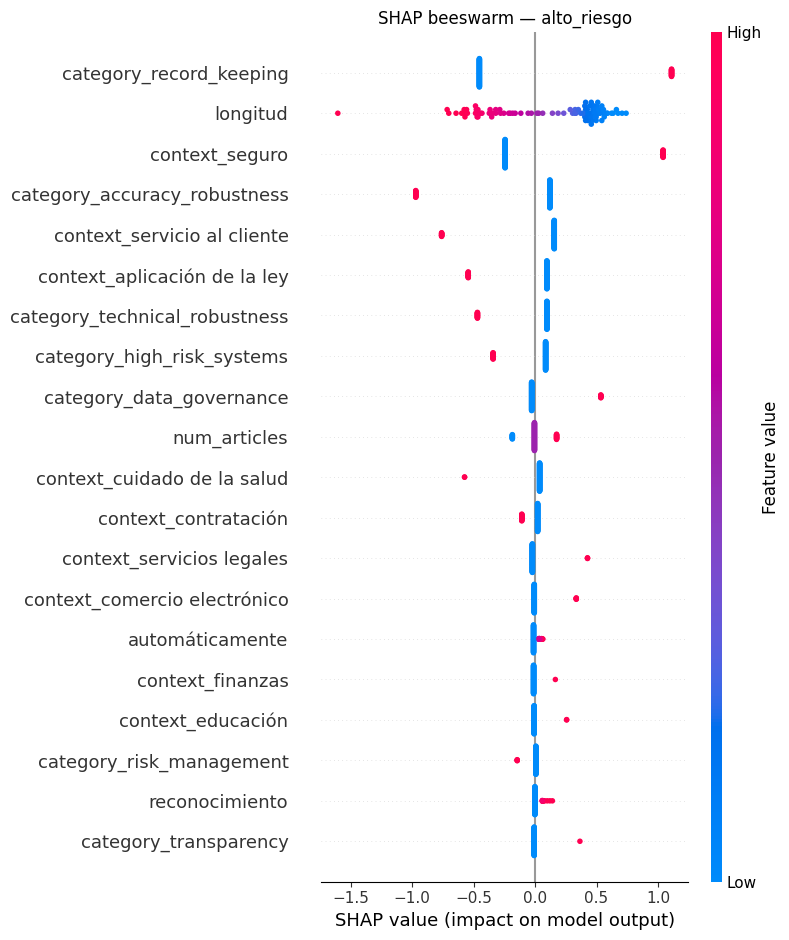

Guardado: model\shap_beeswarm_alto_riesgo.png


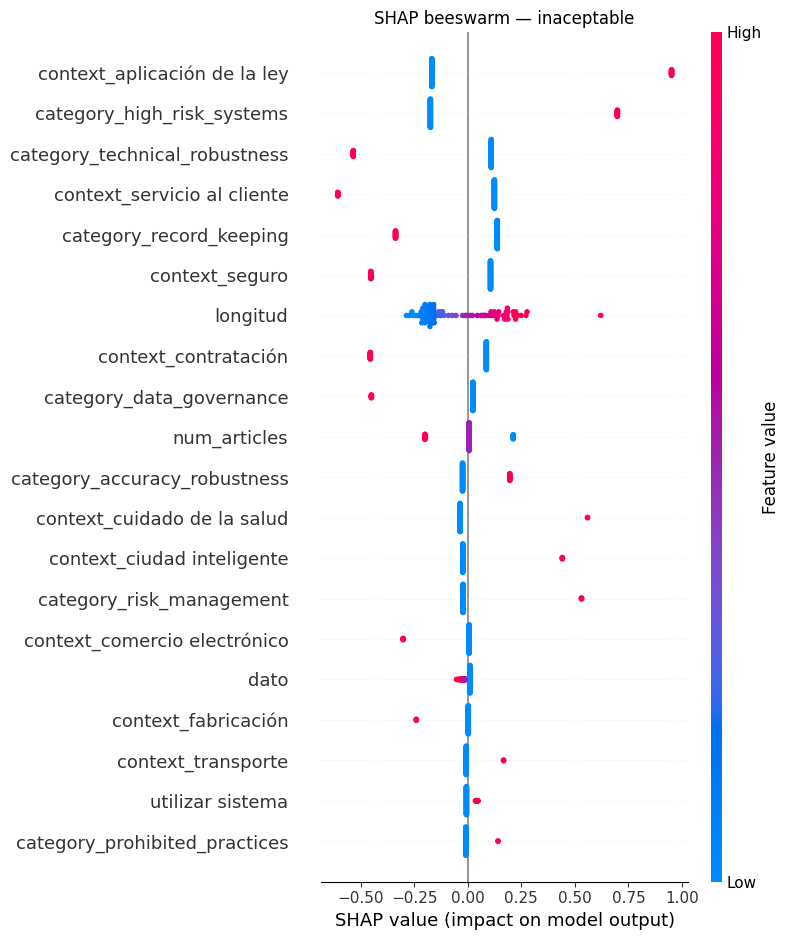

Guardado: model\shap_beeswarm_inaceptable.png


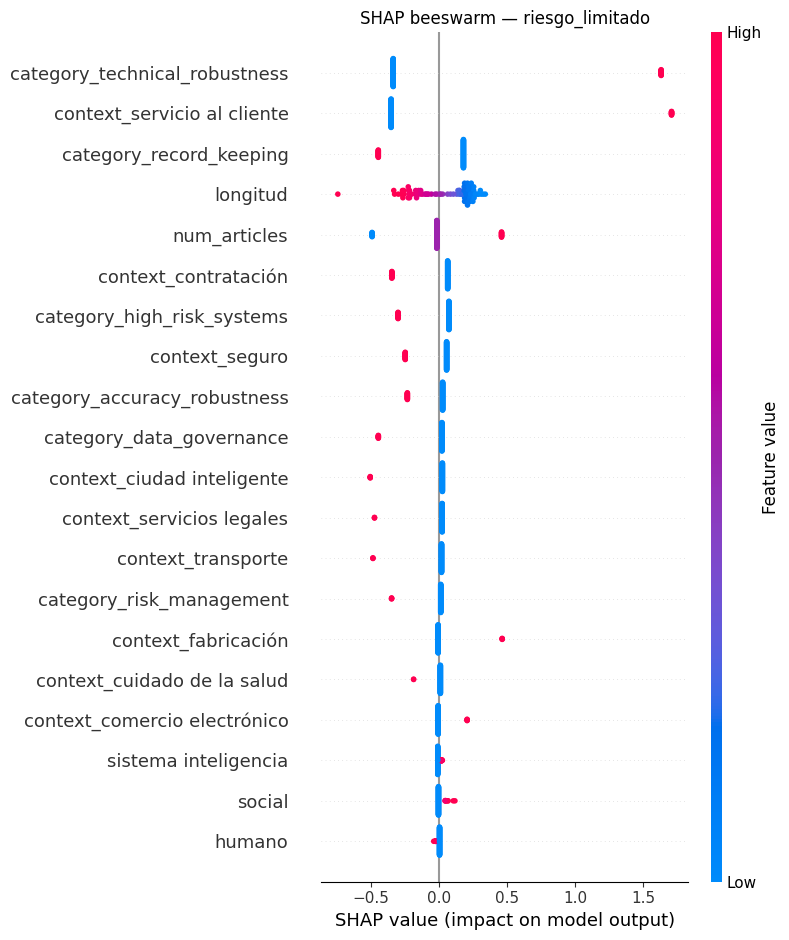

Guardado: model\shap_beeswarm_riesgo_limitado.png


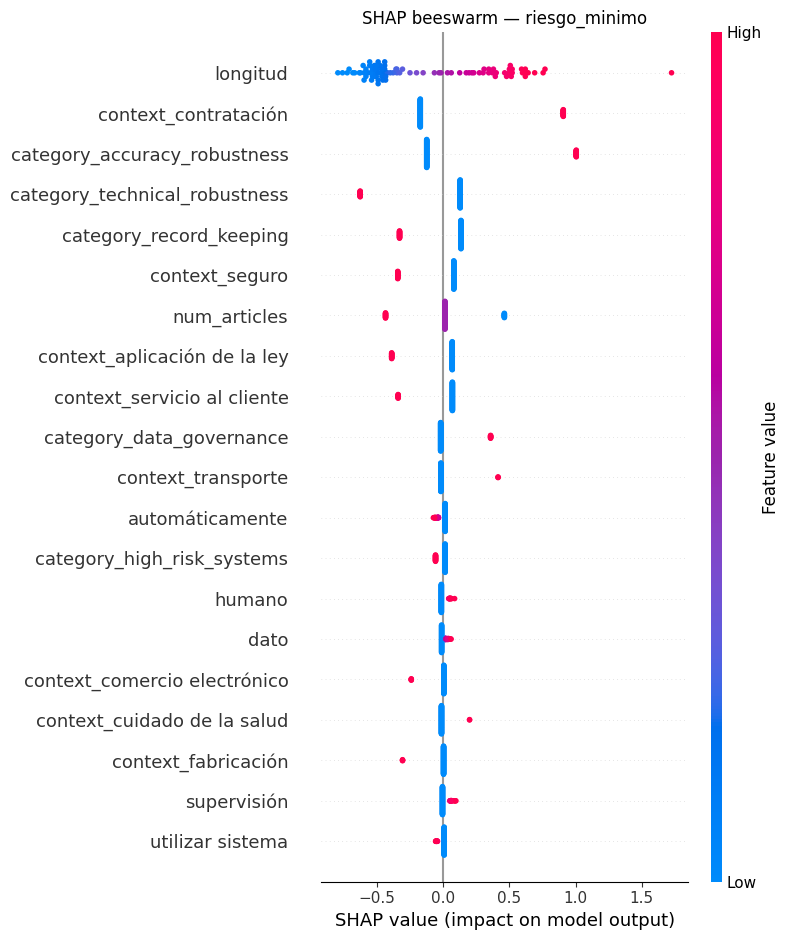

Guardado: model\shap_beeswarm_riesgo_minimo.png


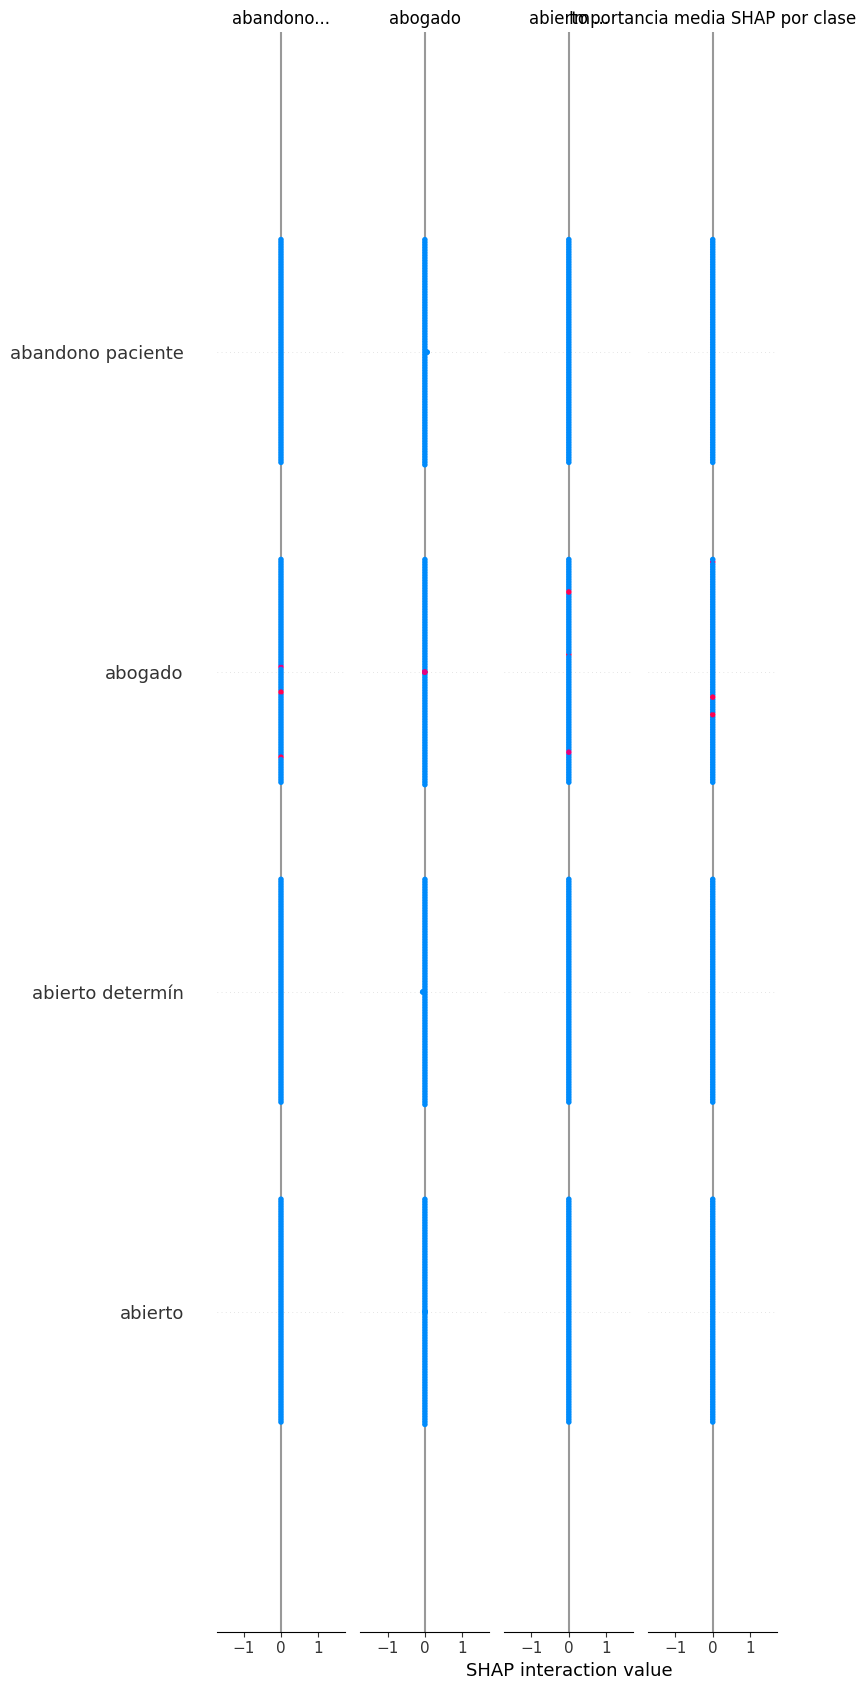

Guardado: model\shap_importancia_clases.png

Plots guardados: ['model\\shap_beeswarm_alto_riesgo.png', 'model\\shap_beeswarm_inaceptable.png', 'model\\shap_beeswarm_riesgo_limitado.png', 'model\\shap_beeswarm_riesgo_minimo.png', 'model\\shap_importancia_clases.png']


In [12]:
from functions import plot_shap_summary

saved_paths = plot_shap_summary(
    shap_values=shap_values,
    X_explain=X_test_final,
    feature_names=feature_names,
    class_names=class_names,
    output_dir="model",
    max_display=20,
)

print(f"\nPlots guardados: {saved_paths}")

## 4. Waterfall plot de ejemplos individuales

Elegimos una muestra de cada clase del test set para visualizar
cómo contribuye cada feature a esa predicción concreta.

In [13]:
from functions import plot_shap_waterfall

# Seleccionar un índice representativo por clase
indices_por_clase = {}
for clase in class_names:
    mask = y_test.values == clase
    if mask.any():
        indices_por_clase[clase] = np.where(mask)[0][0]

print("Índices seleccionados por clase:")
for clase, idx in indices_por_clase.items():
    pred = modelo.predict(X_test_final[idx])[0]
    print(f"  {clase}: idx={idx} | predicho={pred} | texto={X_test_text.iloc[idx][:80]}...")

Índices seleccionados por clase:
  alto_riesgo: idx=0 | predicho=alto_riesgo | texto=plataforma predicar rendimiento académico futuro alumno secundaria determín auto...
  inaceptable: idx=7 | predicho=inaceptable | texto=algoritmo analizar patrón compra supermercado inferir persona consumidora alcoho...
  riesgo_limitado: idx=4 | predicho=riesgo_limitado | texto=chatbot plataforma salud mental simular terapeuta humano certificado informar us...
  riesgo_minimo: idx=1 | predicho=riesgo_minimo | texto=herramienta generación respuesta correo electrónico sugerir borrador respuesta u...



--- Waterfall para clase 'alto_riesgo' (índice 0) ---


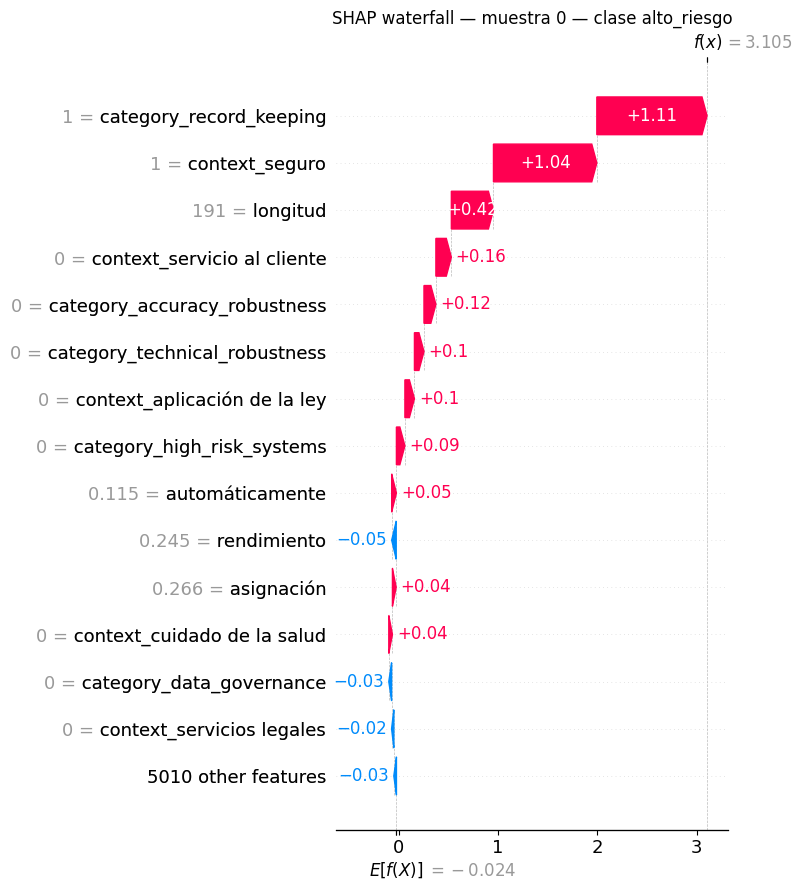

Guardado: model\shap_waterfall_idx0_alto_riesgo.png


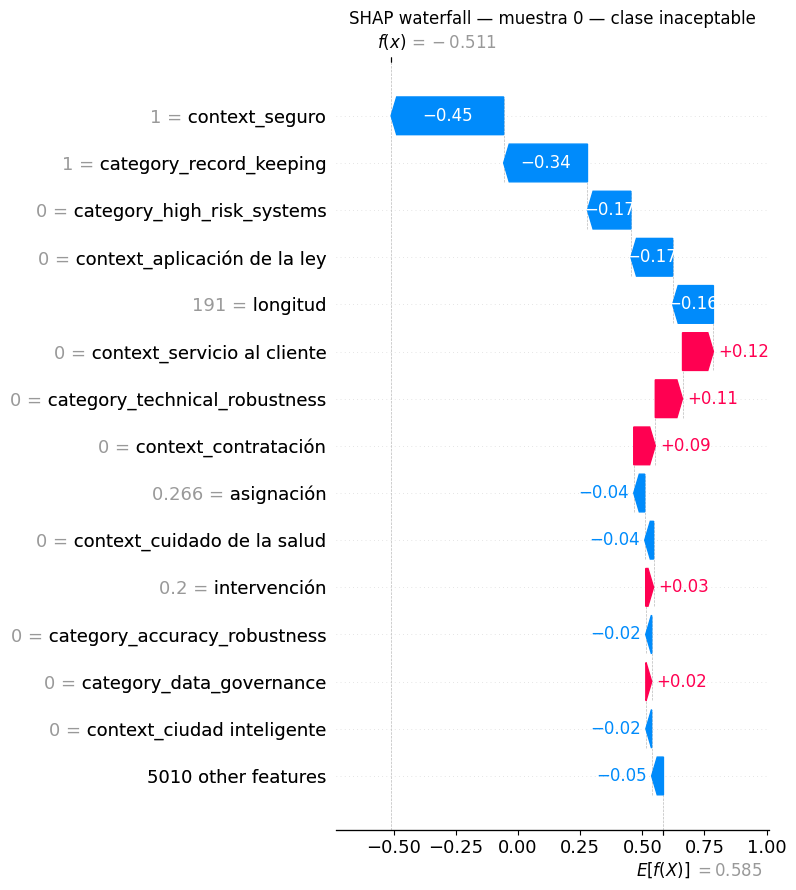

Guardado: model\shap_waterfall_idx0_inaceptable.png


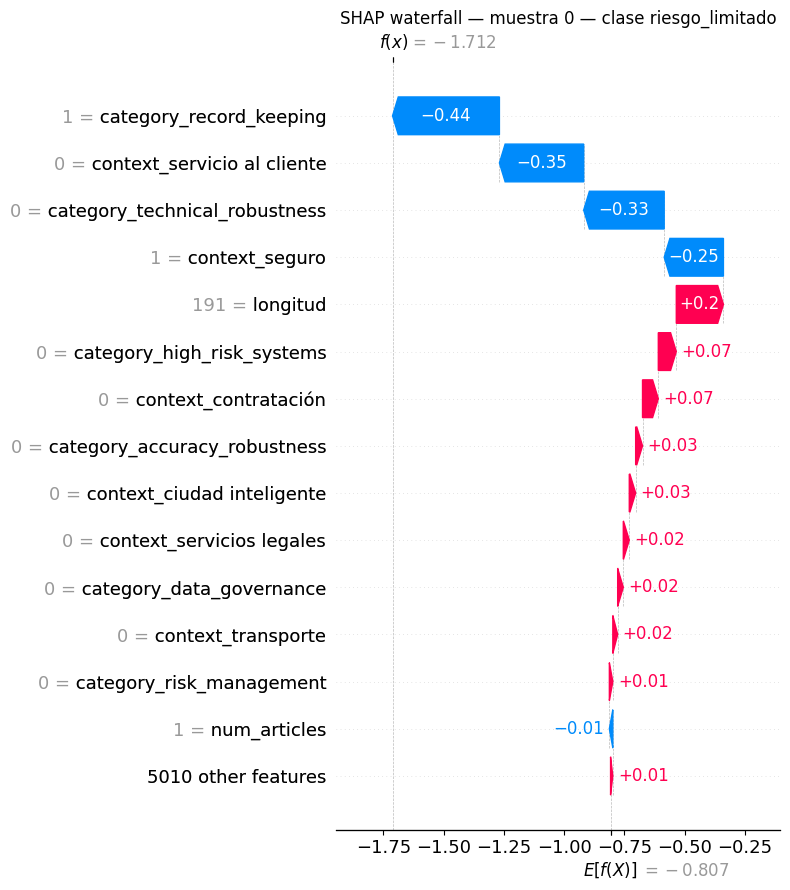

Guardado: model\shap_waterfall_idx0_riesgo_limitado.png


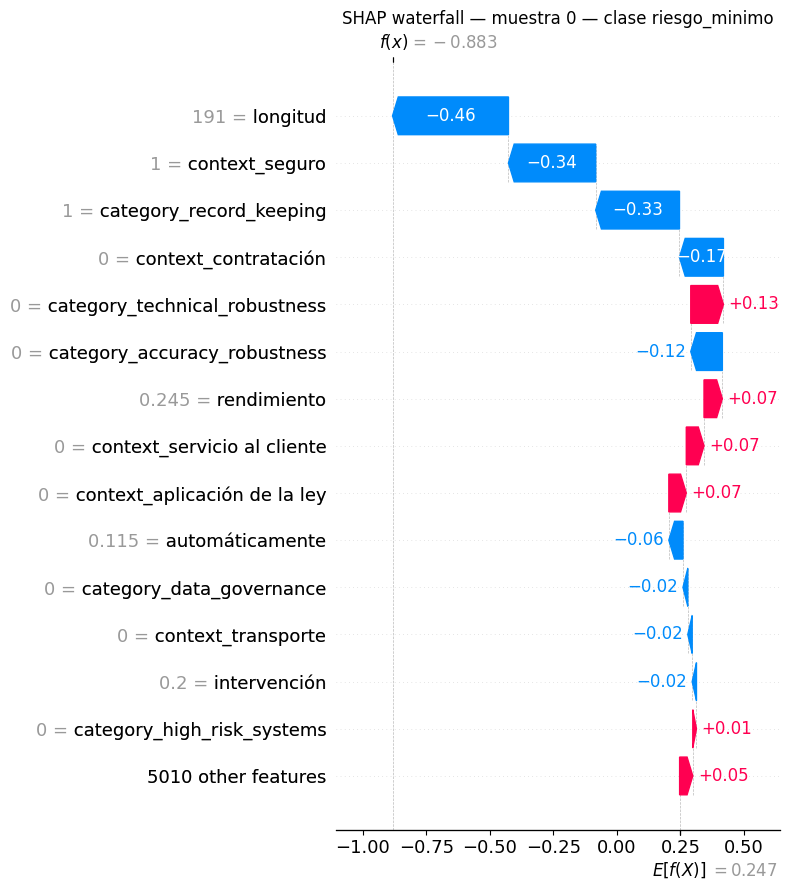

Guardado: model\shap_waterfall_idx0_riesgo_minimo.png

--- Waterfall para clase 'inaceptable' (índice 7) ---


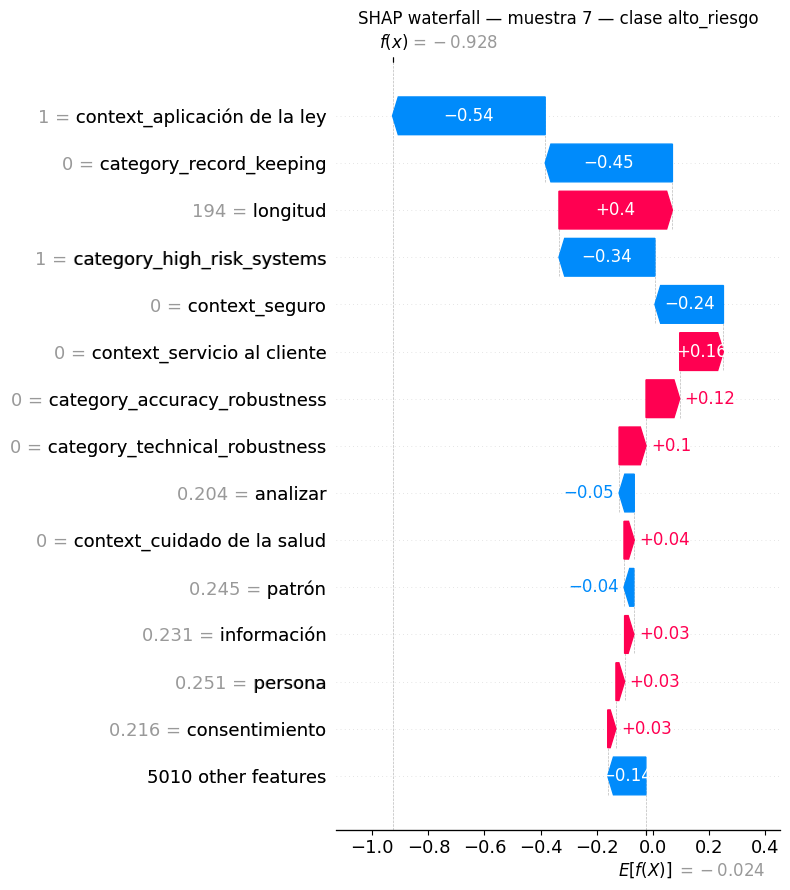

Guardado: model\shap_waterfall_idx7_alto_riesgo.png


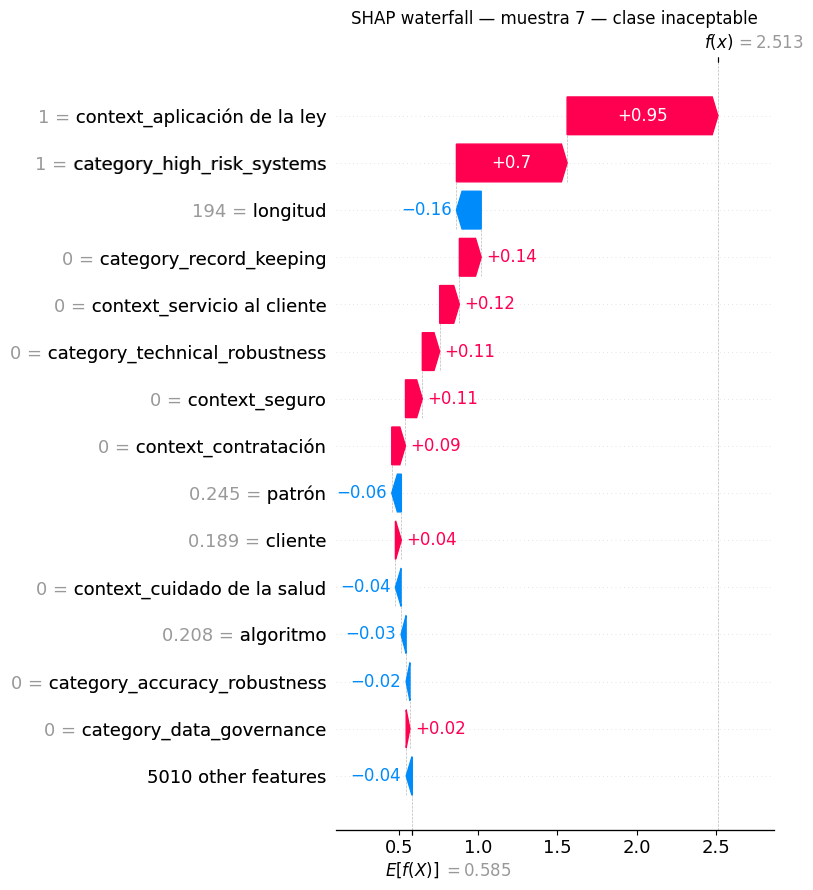

Guardado: model\shap_waterfall_idx7_inaceptable.png


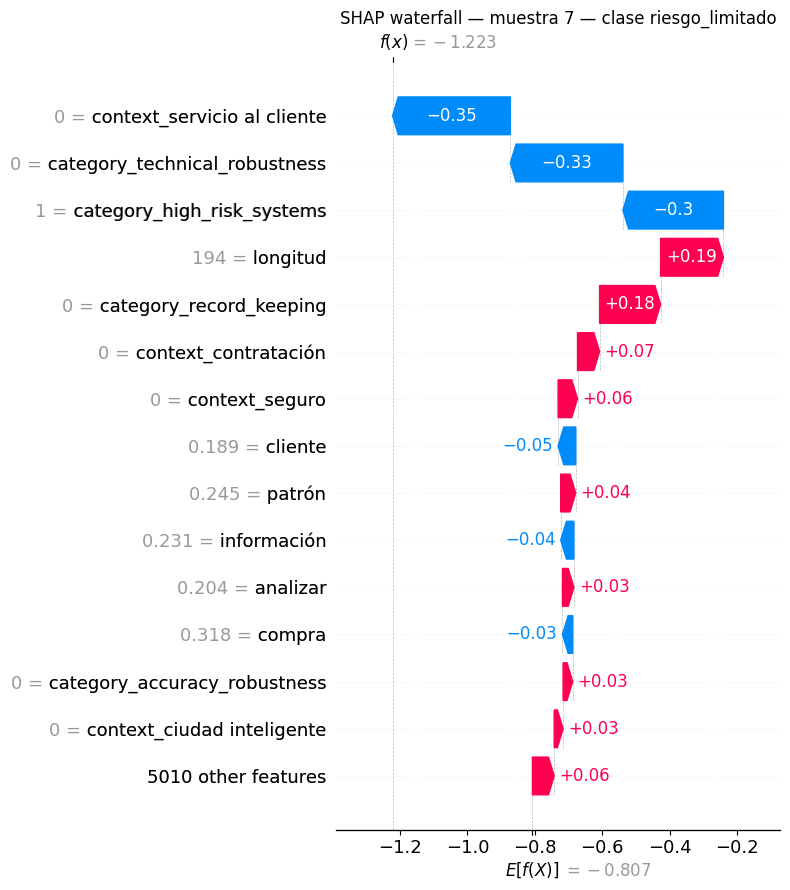

Guardado: model\shap_waterfall_idx7_riesgo_limitado.png


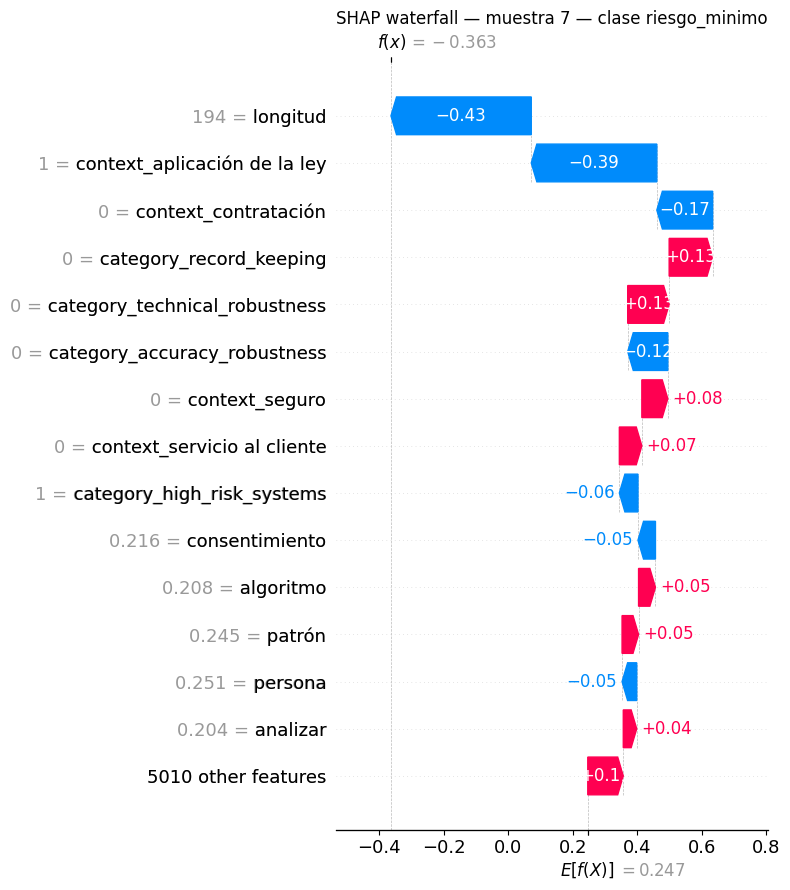

Guardado: model\shap_waterfall_idx7_riesgo_minimo.png

--- Waterfall para clase 'riesgo_limitado' (índice 4) ---


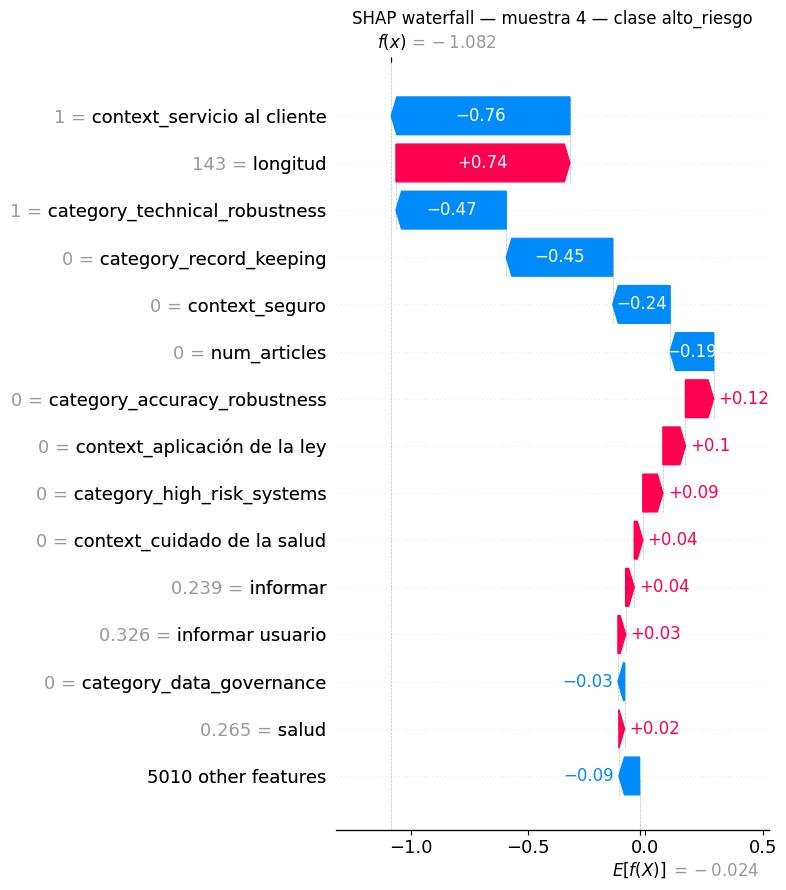

Guardado: model\shap_waterfall_idx4_alto_riesgo.png


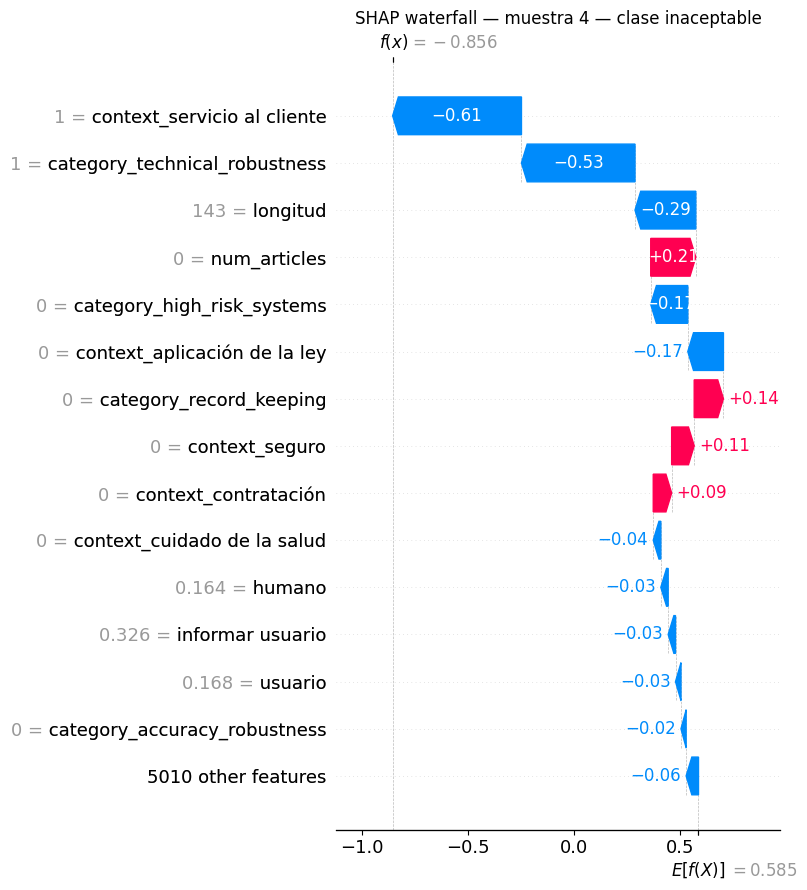

Guardado: model\shap_waterfall_idx4_inaceptable.png


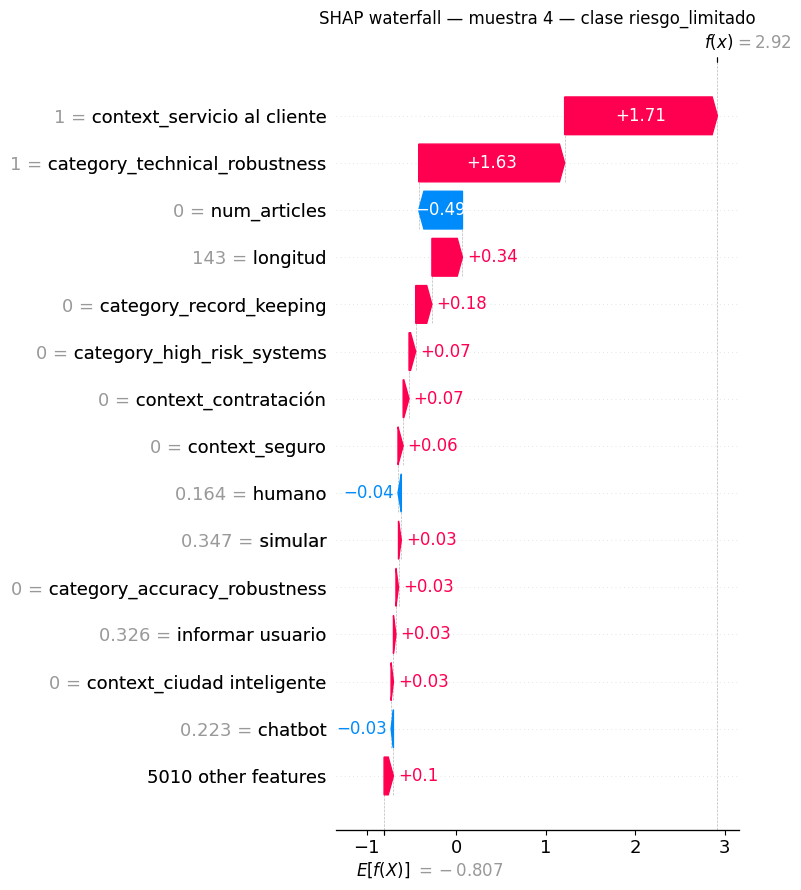

Guardado: model\shap_waterfall_idx4_riesgo_limitado.png


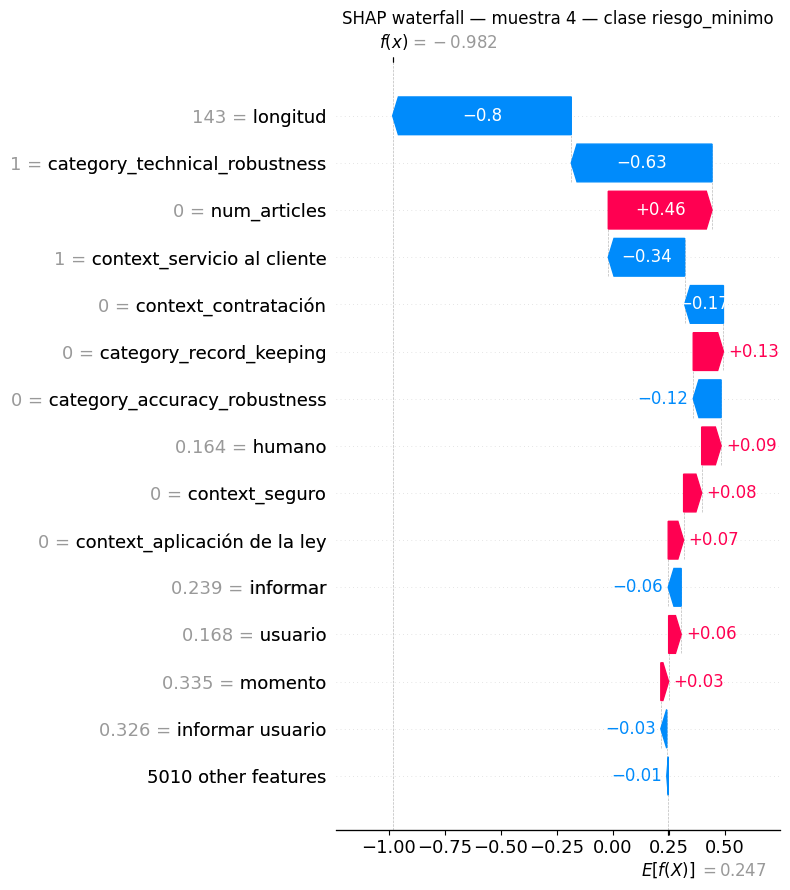

Guardado: model\shap_waterfall_idx4_riesgo_minimo.png

--- Waterfall para clase 'riesgo_minimo' (índice 1) ---


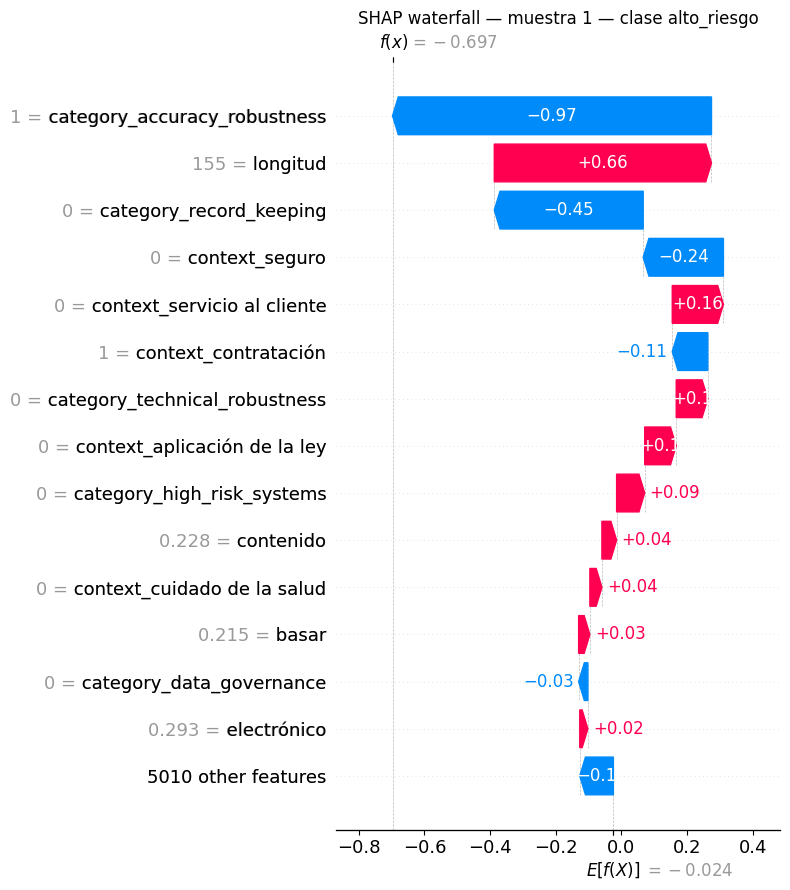

Guardado: model\shap_waterfall_idx1_alto_riesgo.png


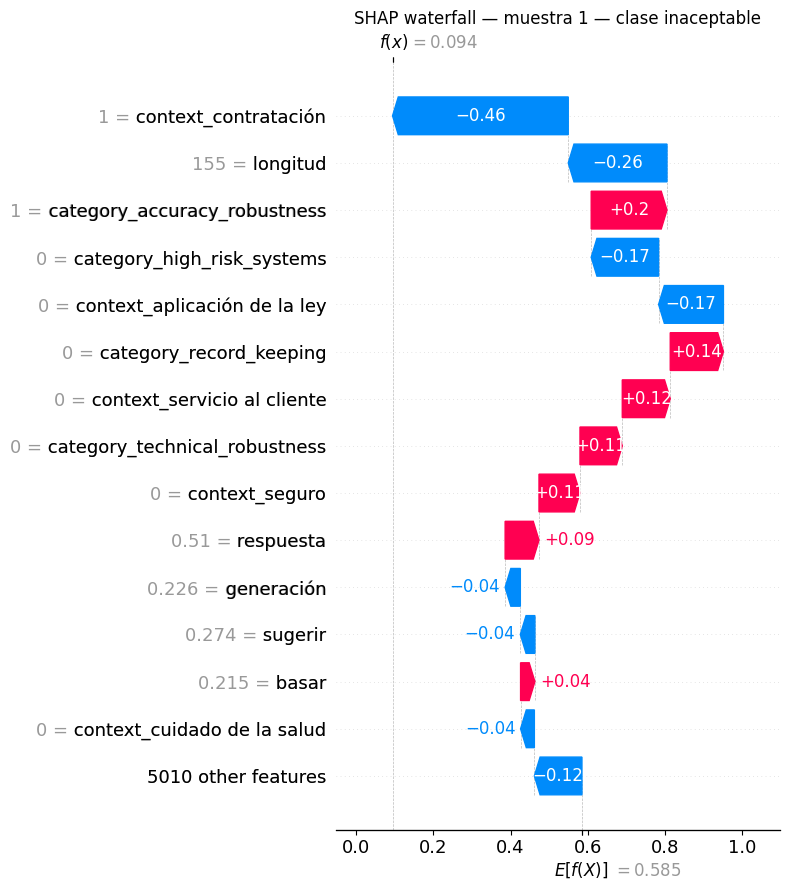

Guardado: model\shap_waterfall_idx1_inaceptable.png


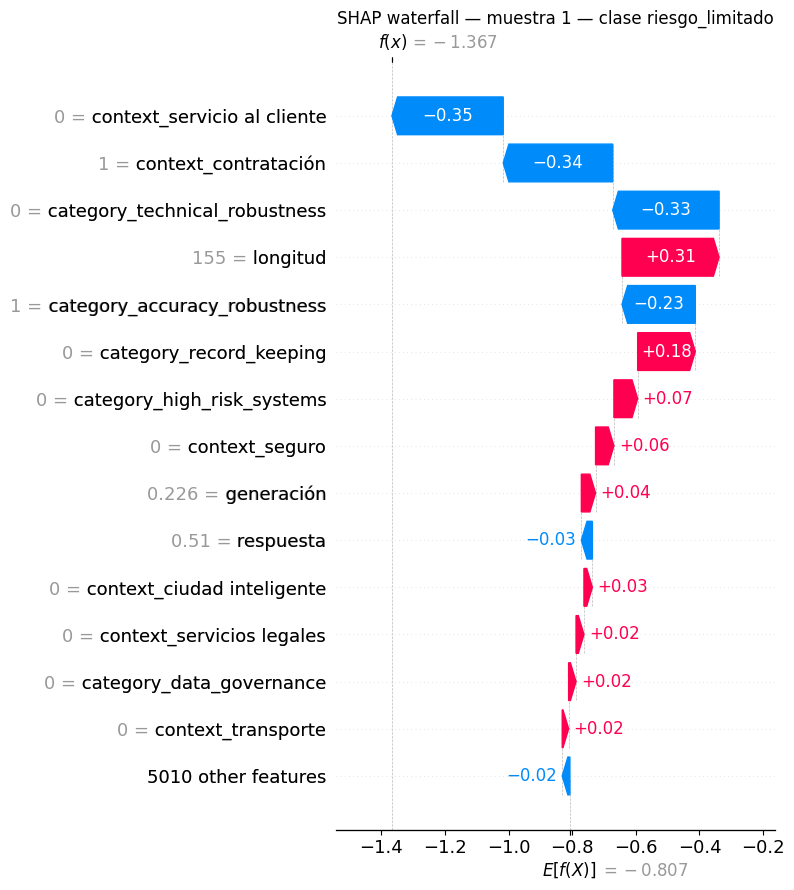

Guardado: model\shap_waterfall_idx1_riesgo_limitado.png


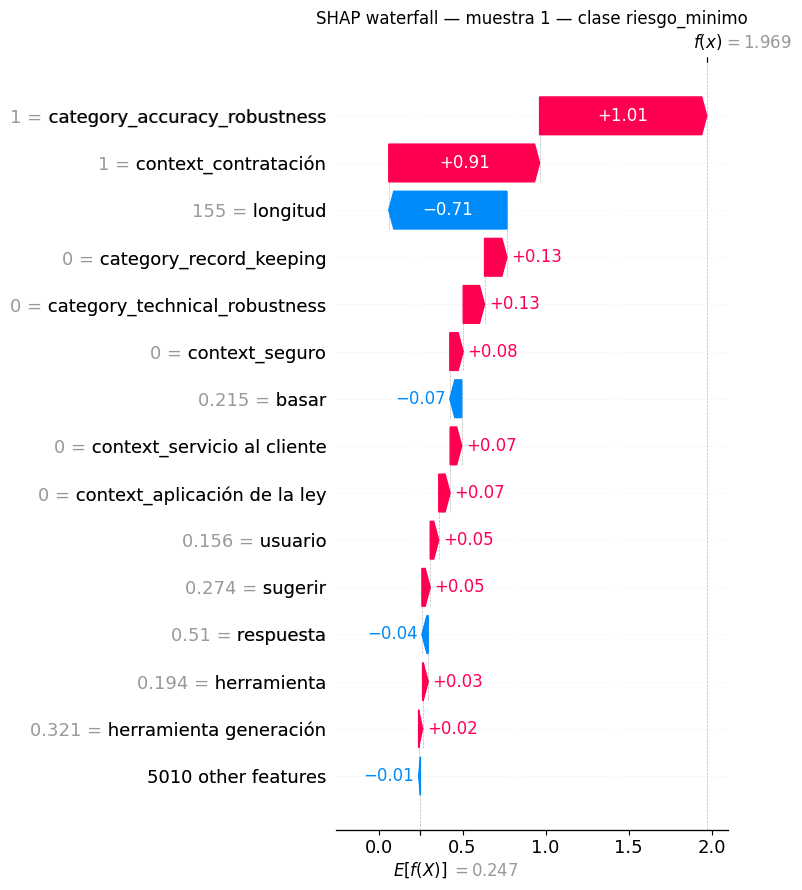

Guardado: model\shap_waterfall_idx1_riesgo_minimo.png


In [14]:
waterfall_paths = []

for clase, idx in indices_por_clase.items():
    print(f"\n--- Waterfall para clase '{clase}' (índice {idx}) ---")
    paths = plot_shap_waterfall(
        explainer=explainer,
        shap_values=shap_values,
        X_explain=X_test_final,
        idx=idx,
        feature_names=feature_names,
        class_names=class_names,
        output_dir="model",
        max_display=15,
    )
    waterfall_paths.extend(paths)

## 5. Interpretación

Documentar aquí las observaciones tras revisar los plots:

- **inaceptable**: ¿qué palabras empujan hacia esta clase?
- **alto_riesgo**: ¿qué términos son más discriminativos?
- **riesgo_limitado**: ¿qué señales usa el modelo?
- **riesgo_minimo**: ¿qué vocabulario es característico?

Coherencia con el AI Act:
- ¿Los features SHAP coinciden con las palabras clave del dominio (`KEYWORDS_DOMINIO`)?
- ¿El modelo está aprendiendo reglas regulatorias o patrones espurios?

## 6. Registro en MLflow

In [15]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
from functions import log_mlflow_safe

all_shap_artifacts = saved_paths + waterfall_paths

try:
    log_mlflow_safe(
        run_name="shap_explicabilidad",
        params={
            "modelo":         "LogisticRegression",
            "explainer_tipo": "LinearExplainer",
            "n_muestras":     X_test_final.shape[0],
            "n_features":     len(feature_names),
            "max_display":    20,
        },
        tags={"experimento": "0", "fase": "explicabilidad"},
        artifacts=all_shap_artifacts,
    )
    print("✓ SHAP registrado en MLflow")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/
⚠ MLflow no disponible: API request to https://18.201.64.41/api/2.0/mlflow/experiments/get-by-name failed with timeout exception HTTPSConnectionPool(host='18.201.64.41', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=clasificador_riesgo_dataset_fusionado (Caused by ConnectTimeoutError(<HTTPSConnection(host='18.201.64.41', port=443) at 0x1b90fef3f80>, 'Connection to 18.201.64.41 timed out. (connect timeout=120)')). To increase the timeout, set the environment variable MLFLOW_HTTP_REQUEST_TIMEOUT (default: 120, type: int) to a larger value.
